SCENARIO - 1

24BAD049 - JESSICA SAM B
Missing values:
 CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


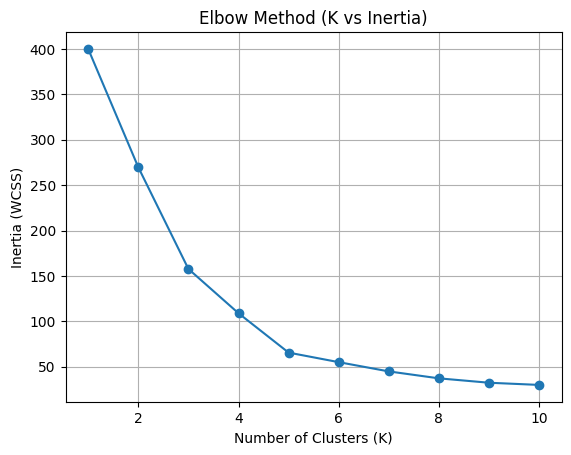

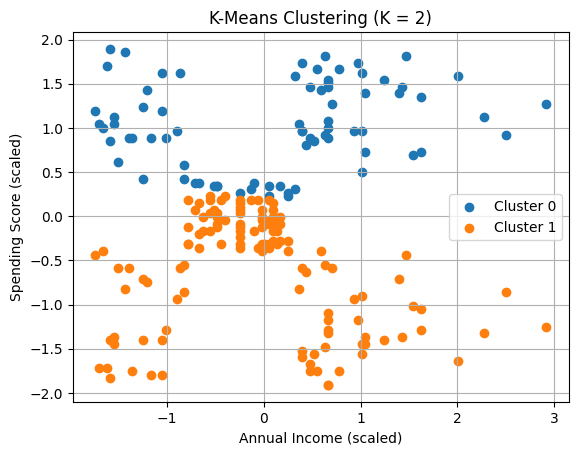

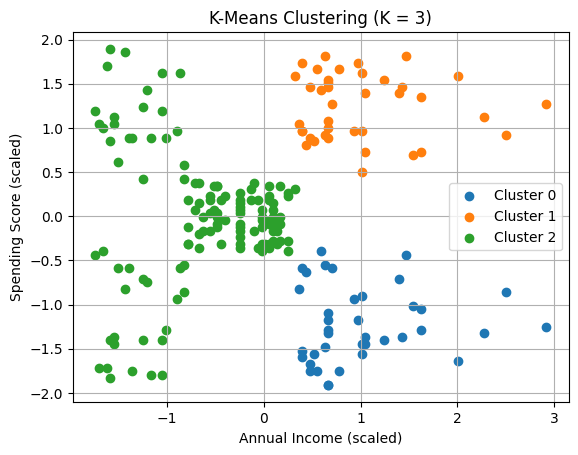

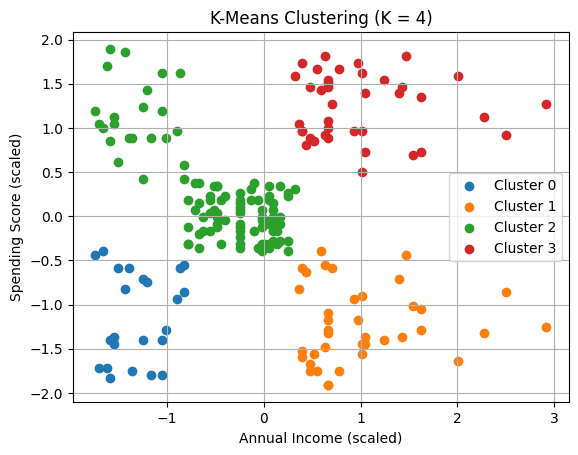

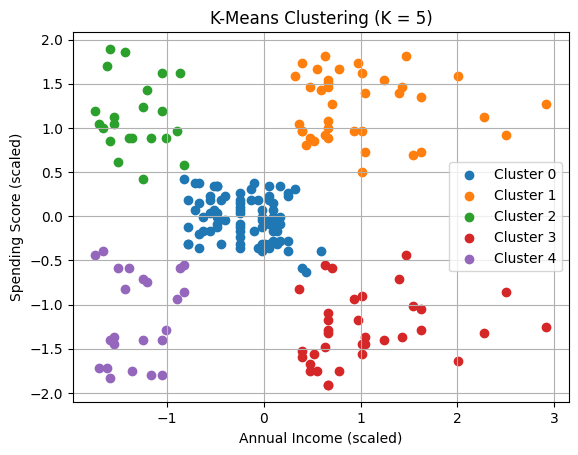


Evaluation Metrics:
Inertia (WCSS): 65.56840815571681
Silhouette Score: 0.5546571631111091


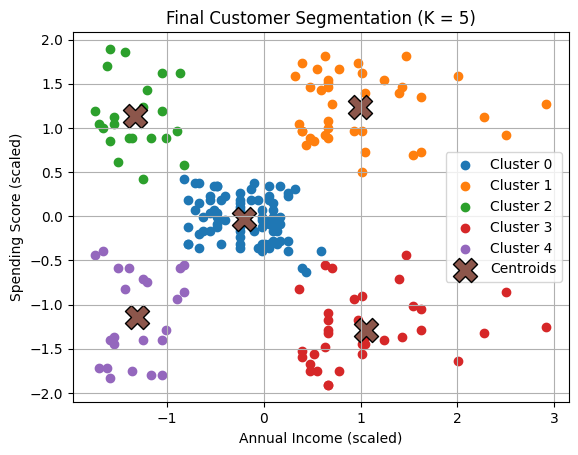


Cluster Summary (Mean Values):
         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                 55.296296               49.518519
1                 86.538462               82.128205
2                 25.727273               79.363636
3                 88.200000               17.114286
4                 26.304348               20.913043

Sensitivity to Initialization (Different Inertia Values):
[65.57885579985046, 65.56840815571681, 98.41025672831277, 98.73371439436362, 65.56840815571681]


In [ ]:
print("24BAD049 - JESSICA SAM B")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

df = pd.read_csv("/content/Mall_Customers.csv")

print("Missing values:\n", df.isnull().sum())
df = df.dropna()

X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure()
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method (K vs Inertia)")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (WCSS)")
plt.grid()
plt.show()

K_values = [2, 3, 4, 5]

for k in K_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(X_scaled)

    plt.figure()
    for i in range(k):
        plt.scatter(
            X_scaled[clusters == i, 0],
            X_scaled[clusters == i, 1],
            label=f'Cluster {i}'
        )

    plt.title(f"K-Means Clustering (K = {k})")
    plt.xlabel("Annual Income (scaled)")
    plt.ylabel("Spending Score (scaled)")
    plt.legend()
    plt.grid()
    plt.show()

k = 5
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

print("\nEvaluation Metrics:")
print("Inertia (WCSS):", kmeans.inertia_)
print("Silhouette Score:", silhouette_score(X_scaled, clusters))

plt.figure()

for i in range(k):
    plt.scatter(
        X_scaled[clusters == i, 0],
        X_scaled[clusters == i, 1],
        label=f'Cluster {i}'
    )

centroids = kmeans.cluster_centers_
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker='X',
    s=300,
    edgecolors='black',
    label='Centroids'
)

plt.title("Final Customer Segmentation (K = 5)")
plt.xlabel("Annual Income (scaled)")
plt.ylabel("Spending Score (scaled)")
plt.legend()
plt.grid()
plt.show()

print("\nCluster Summary (Mean Values):")
summary = df.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean()
print(summary)

inertias = []

for i in range(5):
    kmeans_temp = KMeans(n_clusters=5, random_state=None, n_init=1)
    kmeans_temp.fit(X_scaled)
    inertias.append(kmeans_temp.inertia_)

print("\nSensitivity to Initialization (Different Inertia Values):")
print(inertias)

In [ ]:
SCENARIO - 2

24BAD049 - JESSICA SAM B


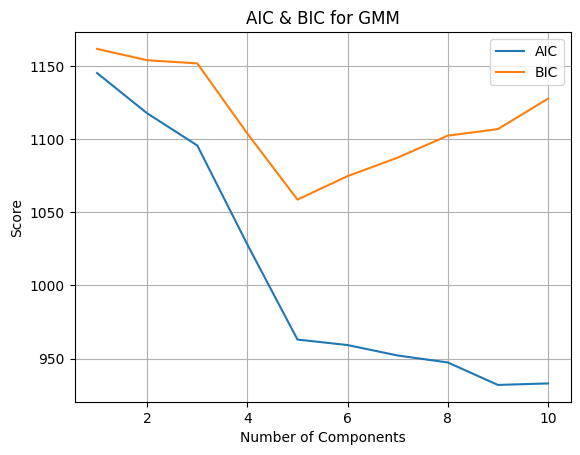

Log-Likelihood: -2.262502621973241
AIC: 963.0010487892964
BIC: 1058.6522524191894
Silhouette Score: 0.5536892843811245


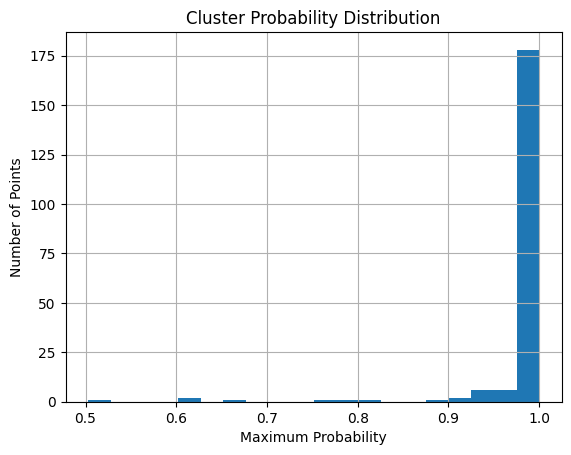

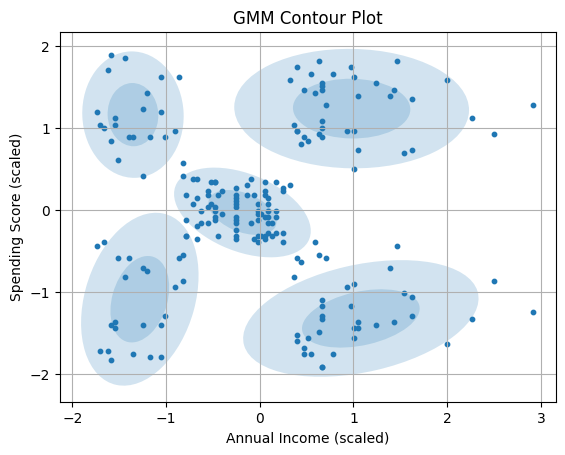

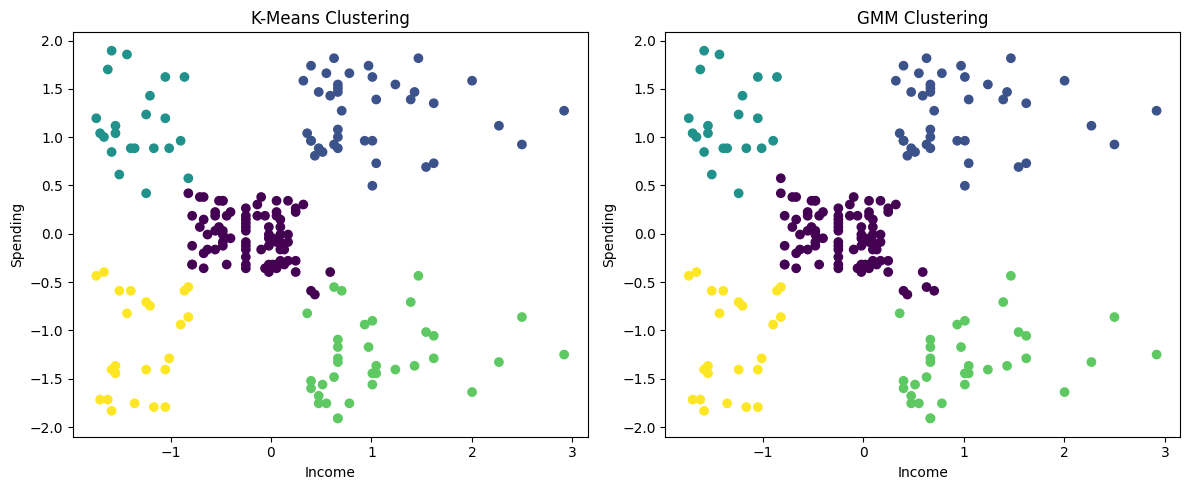

In [ ]:
print("24BAD049 - JESSICA SAM B")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from matplotlib.patches import Ellipse

df = pd.read_csv("/content/Mall_Customers.csv")
df = df.dropna()

X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

aic = []
bic = []
K_range = range(1, 11)

for k in K_range:
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(X_scaled)
    aic.append(gmm.aic(X_scaled))
    bic.append(gmm.bic(X_scaled))

plt.figure()
plt.plot(K_range, aic, label="AIC")
plt.plot(K_range, bic, label="BIC")
plt.title("AIC & BIC for GMM")
plt.xlabel("Number of Components")
plt.ylabel("Score")
plt.legend()
plt.grid()
plt.show()

k = 5
gmm = GaussianMixture(n_components=k, random_state=42)
gmm.fit(X_scaled)

probs = gmm.predict_proba(X_scaled)
clusters = np.argmax(probs, axis=1)

df['Cluster'] = clusters

print("Log-Likelihood:", gmm.score(X_scaled))
print("AIC:", gmm.aic(X_scaled))
print("BIC:", gmm.bic(X_scaled))
print("Silhouette Score:", silhouette_score(X_scaled, clusters))

plt.figure()
plt.hist(np.max(probs, axis=1), bins=20)
plt.title("Cluster Probability Distribution")
plt.xlabel("Maximum Probability")
plt.ylabel("Number of Points")
plt.grid()
plt.show()

def draw_ellipse(position, covariance, ax):
    U, s, Vt = np.linalg.svd(covariance)
    angle = np.degrees(np.arctan2(U[1, 0], U[0, 0]))
    width, height = 2 * np.sqrt(s)
    for nsig in range(1, 3):
        ax.add_patch(Ellipse(xy=position, width=nsig*width, height=nsig*height, angle=angle, alpha=0.2))

plt.figure()
ax = plt.gca()

for i in range(k):
    draw_ellipse(gmm.means_[i], gmm.covariances_[i], ax)

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], s=10)
plt.title("GMM Contour Plot")
plt.xlabel("Annual Income (scaled)")
plt.ylabel("Spending Score (scaled)")
plt.grid()
plt.show()

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=kmeans_labels)
plt.title("K-Means Clustering")
plt.xlabel("Income")
plt.ylabel("Spending")

plt.subplot(1, 2, 2)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters)
plt.title("GMM Clustering")
plt.xlabel("Income")
plt.ylabel("Spending")

plt.tight_layout()
plt.show()